#### Setup and Load Cleaned Dataset

In [13]:
#pip install numpy pandas pathlib pyarrow fastparquet requests scikit-learn matplotlib
#pip install torch --index-url https://download.pytorch.org/whl/cu126
import numpy as np
import pandas as pd
from pathlib import Path
import requests
import sklearn
import matplotlib
#import pyarrow
#import fastparquet

#### Downloading External Data Sources
The taxi zone lookup dataset is downloaded and stored locally. This lookup table contains geographic information that is later used to map pickup and dropoff location IDs to borough names, enriching the dataset with spatial context.

In [14]:
# Create data directory and download the taxi zone lookup dataset if it is not already available locally
raw_path = Path("data/raw")
raw_path.mkdir(parents=True, exist_ok=True)

def download_file(url, save_path):
    if not save_path.exists():  # download file only if it does not already exist
        print(f"Downloading {save_path.name}...")
        response = requests.get(url)
        response.raise_for_status()
        with open(save_path, "wb") as f:
            f.write(response.content)
        print("Download complete.")
    else:
        print(f"{save_path.name} already exists.")  # skip download if file already exists


# Download zone lookup file
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

zone_path = raw_path / "taxi_zone_lookup.csv"
download_file(zone_url, zone_path)  # download lookup table

zones = pd.read_csv(zone_path)  # load zone lookup dataset into a dataframe

taxi_zone_lookup.csv already exists.


### Loads cleaned dataset.
change path here to cleaned dataset path

In [15]:
#change this path to your cleaned data file
CLEAN_PATH = Path("data/processed/cleaned_taxi_2024_01.parquet")

df = pd.read_parquet(CLEAN_PATH, engine="pyarrow")
print("Loaded With Shape:", df.shape)
df.head()

Loaded With Shape: (2869572, 26)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_day_of_week,LocationID,pickup_zone,pickup_date
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,...,22.70,2.5,0.0,19.800000,5.212121,0,Monday,186,Penn Station/Madison Sq West,2024-01-01
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,...,18.75,2.5,0.0,6.600000,16.363636,0,Monday,140,Lenox Hill East,2024-01-01
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,...,31.30,2.5,0.0,17.916667,15.739535,0,Monday,236,Upper East Side North,2024-01-01
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,...,17.00,2.5,0.0,8.300000,10.120482,0,Monday,79,East Village,2024-01-01
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,...,16.10,2.5,0.0,6.100000,7.868852,0,Monday,211,SoHo,2024-01-01


#### Dataset Schema Validation
Before proceeding with feature engineering and modeling, a schema check is performed to ensure that all required columns are present in the cleaned dataset. This helps detect missing or incorrectly loaded fields early in the pipeline.

In [16]:
# Verify that the cleaned dataset contains all required columns for modeling
required_cols = {
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "trip_distance", "fare_amount", "tip_amount",
    "payment_type", "PULocationID", "DOLocationID",
    "passenger_count", "total_amount"
}

# identify any required columns that are missing from the cleaned dataset
missing = required_cols - set(df.columns)  
if missing:
    raise ValueError(f"Cleaned dataset missing required columns: {missing}")  # raise error if schema is incomplete

print("Schema check passed :3")  # confirm dataset contains all required fields

Schema check passed :3


#### Filter for Credit card payments only

To ensure consistent tipping data, the dataset is filtered to include only trips paid by credit card. Credit card transactions reliably record tip amounts, whereas cash payments often do not include recorded tips.

In [17]:
# Filter dataset to include only credit card payments where tip amounts are reliably recorded
df = df[df["payment_type"] == 1].copy()

# display dataset size after filtering
print("Shape after CC filter:", df.shape)  

Shape after CC filter: (2298347, 26)


## Part 1: Data Preprocessing & Feature Engineering

#### Feature engineering

### 1. Feature Engineering

Create temporal, trip, and fare features used by both regression and classification models.

In [18]:
# Ensure datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Temporal features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek

# Weekend indicator (5=Saturday, 6=Sunday)
df["is_weekend"] = df["pickup_day_of_week"].isin([5,6])

# Trip features
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60.0

# trip speed in mph
duration_hours = df["trip_duration_minutes"] / 60.0
# avoid division by zero by setting speed to NaN for trips with zero duration
df["trip_speed_mph"] = np.where(
    duration_hours > 0,
    df["trip_distance"] / duration_hours,
    np.nan
)

# Log trip distance
df["log_trip_distance"] = np.log1p(df["trip_distance"])

# Fare features
df["fare_per_mile"] = np.where(
    df["trip_distance"] > 0,
    df["fare_amount"] / df["trip_distance"],
    np.nan
)

df["fare_per_minute"] = np.where(
    df["trip_duration_minutes"] > 0,
    df["fare_amount"] / df["trip_duration_minutes"],
    np.nan
)

#### 2. Target Variable Creation

Define regression and classification targets. The class distribution of the high-tip variable is also examined.

In [19]:
#Create regression and classification targets based on tip amount and tip percentage
#regression target:actual tip amount
df["tip_amount_target"] = df["tip_amount"]  

#compute tip percentage, avoids division by zero by assigning 0% tip for trips with zero fare
tip_pct = np.where(
    df["fare_amount"] > 0,
    df["tip_amount"] / df["fare_amount"],  
    0
)

#classification target: 1 if tip exceeds 20% of fare (astype converts boolean to int: True=1, False=0)
df["high_tip"] = (tip_pct > 0.20).astype(int) 

#display proportion of high-tip vs non-high-tip trips
print(df["high_tip"].value_counts(normalize=True))  

high_tip
1    0.759326
0    0.240674
Name: proportion, dtype: float64


The target variable high_tip is moderately imbalanced, with roughly 75% of trips falling into the non–high-tip category and about 25% exceeding the 20% tipping threshold.
Because of this imbalance, evaluation metrics such as F1 score and ROC-AUC were emphasized during model selection and hyperparameter tuning, as they provide a more reliable measure of performance than accuracy alone when class distributions are uneven.

#### 1. Feature Engineering Zones Features


##### Merging Borough Information from Zone Lookup

To enrich the dataset with geographic context, borough information is merged from the taxi zone lookup table using pickup and dropoff location IDs. After the merges, temporary join keys are removed to prevent duplicate or unnecessary columns.

In [20]:
# Prepare a smaller lookup table containing only the required zone information
zones_small = zones[["LocationID", "Borough"]].copy()

# Merge pickup borough information using pickup location ID
df = df.merge(
    zones_small,
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    suffixes=("", "_zonePU")
).rename(columns={"Borough": "PU_Borough"})

# Remove temporary join key columns created during the merge
for col in ["LocationID", "LocationID_zonePU"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Merge dropoff borough information using dropoff location ID
df = df.merge(
    zones_small,
    left_on="DOLocationID",
    right_on="LocationID",
    how="left",
    suffixes=("", "_zoneDO")
).rename(columns={"Borough": "DO_Borough"})

# Remove temporary join key columns created during the merge
for col in ["LocationID", "LocationID_zoneDO"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Check proportion of missing borough values after merge
print("Missing PU borough %:", df["PU_Borough"].isna().mean())
print("Missing DO borough %:", df["DO_Borough"].isna().mean())

# Verify remaining location-related columns
print([c for c in df.columns if "LocationID" in c])

Missing PU borough %: 0.00013487954603895756
Missing DO borough %: 0.003414192896024839
['PULocationID', 'DOLocationID']


#### Cleaning Merge Artifacts

After merging the taxi trip dataset with zone lookup tables, some intermediate merge key columns may remain in the dataframe. These columns are removed to avoid redundancy and ensure that only relevant modeling features remain.

In [21]:
# Remove leftover merge key columns created during earlier dataset joins
to_drop = [c for c in df.columns if c.startswith("LocationID_")]
if to_drop:
    df = df.drop(columns=to_drop)

# verify remaining location related columns
print("Remaining LocationID-like columns:", [c for c in df.columns if "LocationID" in c])

Remaining LocationID-like columns: ['PULocationID', 'DOLocationID']


#### Selecting Features for Modeling Dataframe

The final modeling dataset includes engineered temporal, trip, and fare-related features, along with categorical location variables and core trip attributes. These features are selected based on their potential relevance for predicting both tip amount (regression) and high-tip behavior (classification). Invalid values such as infinities are removed and rows with missing values are dropped to ensure clean model input.

In [22]:
# Define the feature set and target variables used for modeling
model_cols = [
    # engineered temporal + trip + fare
    "pickup_hour", "pickup_day_of_week", "is_weekend",
    "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute",

    # zone features (categorical)
    "PU_Borough", "DO_Borough",

    # extra numeric features allowed
    "passenger_count", "trip_distance", "fare_amount", "total_amount",

    # targets
    "tip_amount_target", "high_tip"
]

# Prepare the final modeling dataset by selecting relevant columns and removing invalid values
df_model = df[model_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
print("Final modeling shape:", df_model.shape) # display number of rows and columns in modeling dataset
print(df_model.dtypes) # display data types of each feature

Final modeling shape: (2290381, 16)
pickup_hour                int32
pickup_day_of_week         int32
is_weekend                  bool
trip_duration_minutes    float64
trip_speed_mph           float64
log_trip_distance        float64
fare_per_mile            float64
fare_per_minute          float64
PU_Borough                   str
DO_Borough                   str
passenger_count          float64
trip_distance            float64
fare_amount              float64
total_amount             float64
tip_amount_target        float64
high_tip                   int64
dtype: object


We retained ~2.29 million rows which indicates a strong dataset size.

#### Train–Validation–Test Split 70/15/15 (stratified on high_tip):

The dataset is divided into training, validation, and test sets. First, a 15% test set is separated to provide an unbiased final evaluation. The remaining data is then split into training and validation sets. Stratified sampling is used to preserve the class distribution of the high_tip target across all splits.

In [ ]:
# Split dataset into training, validation, and test sets while preserving class distribution
from sklearn.model_selection import train_test_split

# features used for modeling
X = df_model.drop(columns=["tip_amount_target", "high_tip"])
# regression target (tip amount)  
y_reg = df_model["tip_amount_target"].values
# classification target (high tip indicator)
y_clf = df_model["high_tip"].values  

# First split: create held-out test set
X_trainval, X_test, y_reg_trainval, y_reg_test, y_clf_trainval, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.15, random_state=42, stratify=y_clf
)

# Second split: divide remaining data into training and validation sets
val_size = 0.15 / 0.85
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_trainval, y_reg_trainval, y_clf_trainval, test_size=val_size, random_state=42, stratify=y_clf_trainval
)

# display dataset sizes
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)  

# Helper function to inspect class distribution in each split
def show_dist(name, y):
    # compute normalized class proportions adn display distribution as dictionary
    s = pd.Series(y).value_counts(normalize=True).sort_index()  
    print(f"{name} high_tip distribution:", s.to_dict())  

show_dist("Train", y_clf_train)
show_dist("Val", y_clf_val)
show_dist("Test", y_clf_test)

Train: (1603266, 14) Val: (343557, 14) Test: (343558, 14)
Train high_tip distribution: {0: 0.23992026276363373, 1: 0.7600797372363662}
Val high_tip distribution: {0: 0.2399194311278769, 1: 0.7600805688721232}
Test high_tip distribution: {0: 0.23991873279038764, 1: 0.7600812672096123}


Train/Val/Test split corresponds to 70/15/15 ratio  
where each split shows a stratification of ~ 24%-76% split with respect to class 1 - class 0

#### Preprocessing pipeline (scale numeric on train only, one-hot boroughs)

To improve memory efficiency on this large dataset, the preprocessing pipeline was configured to preserve sparse matrix output,  preventing unnecessary densification during scaling and one-hot encoding.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric feature list scaled removed total amount to prevent leakage
numeric_features = [
    "pickup_hour", "pickup_day_of_week",
    "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute",
    "passenger_count", "trip_distance", "fare_amount", 
    #"total_amount",
    "is_weekend"  
]

# Categorical feature list (one-hot encoded)
categorical_features = ["PU_Borough", "DO_Borough"]

# Scale numeric features without centering to keep matrix sparse-friendly
numeric_transformer = StandardScaler(with_mean=False)

# One-hot encode boroughs and keep output sparse
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Combine numeric scaling + categorical encoding into one pipeline
# sparse_threshold=1.0 keeps output sparse to reduce memory usage
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Preprocessor ready (memory-efficient).")

Numeric features: ['pickup_hour', 'pickup_day_of_week', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'passenger_count', 'trip_distance', 'fare_amount', 'is_weekend']
Categorical features: ['PU_Borough', 'DO_Borough']
Preprocessor ready (memory-efficient).


Numerical and Categorical features verified.

## Part 2: Model Training & Tuning

#### Baseline Models

Because the training set is very large (~1.6M rows), the RandomForest models were constrained (shallower trees, fewer trees, and   subsampling per tree) to reduce runtime and memory usage on a my laptop while still providing a valid nonlinear   baseline for comparison.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_recall_fscore_support, roc_auc_score
)

#Regression pipelines
#linear regression pipeline
linreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

#random forest regression pipeline and the parameters are set to reduce overfitting and memory usage while maintaining reasonable performance on large datasets
rfreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=30,        # fewer trees = much faster + less memory (baseline model)
        max_depth=14,           # cap tree depth to prevent overly large trees on 1.6M rows
        min_samples_leaf=30,    # force leaves to have enough samples (reduces overfitting + size)
        min_samples_split=60,   # require more samples to split (limits tree growth)
        max_features="sqrt",    # standard RF default for stability/speed
        bootstrap=True,         # needed for max_samples to take effect
        max_samples=0.20,       # each tree trains on 20% of rows (memory reduction)
        n_jobs=1,               # Windows stability: prevents memory duplication when using multiple processes
        random_state=42
    ))
])

#Classification pipelines
#logistic regression pipeline
logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,          # allow more iterations so it converges on large data
        solver="lbfgs"          # stable default solver for binary classification
    ))
])

#random forest classification pipeline
rfclf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=30,        
        max_depth=14,           
        min_samples_leaf=30,    
        min_samples_split=60,   
        max_features="sqrt",    
        bootstrap=True,         
        max_samples=0.20,       
        n_jobs=1,               
        random_state=42
    ))
])

#### Training Baseline Models (fit models) with timing

To compare the computational cost of each model, a helper function is used to measure the time required to fit each pipeline on the training data. This provides insight into the relative training efficiency of linear models versus tree-based models.

In [26]:
# Define a helper function to measure and display training time for each model pipeline
import time

def timed_fit(name, pipe, X, y):
    t0 = time.time()  # record start time before model training
    pipe.fit(X, y)  # train the model pipeline on the provided data
    print(f"{name} fit time: {time.time() - t0:.1f}s")  # print elapsed training time

# Train models and report training time for each
timed_fit("LinearRegression", linreg_pipe, X_train, y_reg_train)
timed_fit("LogisticRegression", logreg_pipe, X_train, y_clf_train)
timed_fit("RF Regressor", rfreg_pipe, X_train, y_reg_train)
timed_fit("RF Classifier", rfclf_pipe, X_train, y_clf_train)

LinearRegression fit time: 4.2s
LogisticRegression fit time: 9.8s
RF Regressor fit time: 184.7s
RF Classifier fit time: 136.9s


#### Validation evaluation funtions:

The following functions evaluate model performance on the validation dataset. Separate evaluation functions are defined for regression and classification tasks, computing standard metrics such as MAE, RMSE, and R² for regression, and Accuracy, Precision, Recall, F1-score, and ROC-AUC for classification. These results allow comparison of baseline models before hyperparameter tuning and final testing.

In [27]:
# Import evaluation metrics and define helper functions to assess regression and classification models on the validation set
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# Define evaluation function for regression models
def eval_reg(pipe, Xv, yv):
    pred = pipe.predict(Xv)  # generate predictions from regression model
    return {
        "MAE": mean_absolute_error(yv, pred),  # compute mean absolute error
        "RMSE": np.sqrt(mean_squared_error(yv, pred)),  # compute root mean squared error
        "R2": r2_score(yv, pred)  # compute coefficient of determination
    }

# Define evaluation function for classification models
def eval_clf(pipe, Xv, yv):
    pred = pipe.predict(Xv)  # generate predicted class labels
    proba = pipe.predict_proba(Xv)[:, 1]  # obtain predicted probabilities for positive class
    return {
        "Accuracy": accuracy_score(yv, pred),  # compute classification accuracy
        "Precision": precision_score(yv, pred, zero_division=0),  # compute precision
        "Recall": recall_score(yv, pred, zero_division=0),  # compute recall
        "F1": f1_score(yv, pred, zero_division=0),  # compute F1-score
        "ROC_AUC": roc_auc_score(yv, proba)  # compute area under ROC curve
    }

# Create validation comparison tables for regression and classification models
reg_table = pd.DataFrame({
    "LinearRegression": eval_reg(linreg_pipe, X_val, y_reg_val),
    "RFRegressor": eval_reg(rfreg_pipe, X_val, y_reg_val)
}).T

clf_table = pd.DataFrame({
    "LogisticRegression": eval_clf(logreg_pipe, X_val, y_clf_val),
    "RFClassifier": eval_clf(rfclf_pipe, X_val, y_clf_val)
}).T

print("Regression (Validation):")  # print regression validation results
display(reg_table)

print("Classification (Validation):")  # print classification validation results
display(clf_table)

Regression (Validation):


,MAE,RMSE,R2
LinearRegression,1.248597,2.291718,0.611388
RFRegressor,1.191017,2.185691,0.646515


Classification (Validation):


,Accuracy,Precision,Recall,F1,ROC_AUC
LogisticRegression,0.765684,0.766146,0.995619,0.865938,0.596749
RFClassifier,0.770286,0.768601,0.998342,0.868536,0.618112


### Validation Results and Baseline Comparison

For the regression task, both Linear Regression and the Random Forest Regressor perform reasonably well on the validation set. Linear Regression achieves an R² of approximately 0.61, while the Random Forest Regressor achieves a slightly higher R² of about 0.65, indicating that the tree-based model captures somewhat more variance in the tip amount. The Random Forest also produces lower MAE and RMSE values, suggesting improved predictive accuracy compared with the linear model. This improvement likely arises from the Random Forest’s ability to model nonlinear relationships between trip characteristics and tipping behavior.

For the classification task, both models achieve similar overall performance. Logistic Regression reaches an accuracy of about 0.766 and an F1 score of 0.866, while the Random Forest classifier achieves a slightly higher accuracy of 0.770 and an F1 score of 0.869. The ROC–AUC values are relatively modest, with Logistic Regression achieving approximately 0.597 and the Random Forest achieving 0.618, indicating only moderate separation between high-tip and non-high-tip trips.

Both models exhibit extremely high recall (around 0.996–0.998), suggesting that the models tend to identify most high-tip trips correctly but may also classify many borderline cases as high-tip. The Random Forest provides a small improvement in ROC–AUC and overall accuracy, indicating that nonlinear feature interactions offer a slight benefit for the classification task.

Overall, the baseline results suggest that nonlinear models provide a modest advantage for both regression and classification, although the improvements over the linear baselines are relatively small.

### Hyperparametric Tuning

Given the large size of the training dataset (~1.6M rows), hyperparameter tuning was performed on a stratified random sample of 300,000 rows to reduce computational cost while maintaining representativeness of the full training dataset.

A randomized search with cross-validation was used to explore key Random Forest hyperparameters controlling tree complexity and sampling behaviour. The objective was to determine whether improved validation performance could be achieved beyond the constrained baseline configuration.

The tuned model is evaluated on the full validation set after selection. The test set remains untouched at this stage to avoid data leakage.

In [ ]:
# Import hyperparameter tuning utility and create a random subset of the training data for efficient tuning
from sklearn.model_selection import RandomizedSearchCV

# Use 300k rows for tuning 
N_TUNE = 300000

# initialize random generator for reproducibility
rng = np.random.RandomState(42)  
# randomly sample indices from training data
indices = rng.choice(len(X_train), size=N_TUNE, replace=False)  

# select sampled feature rows for tuning adn corresponding sampled labels for classification target
X_tune = X_train.iloc[indices]  
y_clf_tune = y_clf_train[indices]

print("Tuning subset shape:", X_tune.shape) 

Tuning subset shape: (300000, 14)


#### Define Parameter Grid 

Hyperparameter Search Space  
The following parameter grid defines the range of hyperparameters explored during randomized search for the Random Forest classifier. These parameters control tree depth, sampling behavior, and feature selection, allowing the model to balance complexity, generalization, and computational efficiency.

In [29]:
# Define the hyperparameter search space for Random Forest tuning
param_dist = {
    "model__n_estimators": [30, 50, 70],  # number of trees in the forest
    "model__max_depth": [12, 16, 20],  # maximum depth of each decision tree
    "model__min_samples_leaf": [10, 20, 40],  # minimum samples required at leaf nodes
    "model__max_samples": [0.10, 0.20, 0.30],  # fraction of training data used for each tree
    "model__max_features": ["sqrt", 0.5]  # number of features considered when splitting nodes
}

Run Randomized Search (Classification First)

RandomizedSearchCV is used to tune the hyperparameters of the Random Forest classifier. The search evaluates multiple parameter combinations using 5-fold cross-validation and selects the model that achieves the best F1-score, which is appropriate for the moderately imbalanced classification problem.

In [31]:
# Perform randomized hyperparameter search for the Random Forest classifier using 5-fold cross-validation
rf_tune = RandomizedSearchCV(
    rfclf_pipe,
    param_distributions=param_dist,
    n_iter=20,                # number of random parameter combinations to evaluate
    scoring="f1",             # optimize model selection based on F1-score
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1                 
)

# run hyperparameter search on the tuning subset
rf_tune.fit(X_tune, y_clf_tune)  

# display best hyperparameter configuration and corresponding cross-validation F1 score
print("Best parameters:", rf_tune.best_params_)  
print("Best CV F1:", rf_tune.best_score_)  

# retrieve the tuned Random Forest model
best_rfclf = rf_tune.best_estimator_  

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'model__n_estimators': 70, 'model__min_samples_leaf': 10, 'model__max_samples': 0.3, 'model__max_features': 0.5, 'model__max_depth': 16}
Best CV F1: 0.8687499925611126


#### Hyperparameter Tuning Results (Random Forest Classifier)

A randomized search with 5-fold cross-validation was conducted over 20 parameter combinations, resulting in 100 total model fits, using a sampled subset of the training data.

The best-performing configuration was:
n_estimators = 70  
max_depth = 16  
min_samples_leaf = 10  
max_samples = 0.3  
max_features = 0.5

The best cross-validated F1 score achieved during tuning was 0.869.

These results suggest that the model benefits from a moderately deeper tree structure, a larger number of trees, and increased row and feature subsampling compared with the constrained baseline. At the same time, the use of a minimum leaf size of 10 still provides regularization, helping control overfitting while allowing the model to capture useful nonlinear relationships in the data.

#### Random Forest Validation Performance (Baseline vs Tuned) Code

After hyperparameter tuning, the best Random Forest model from the randomized search is selected and evaluated on the validation set. The validation performance of the tuned model is then compared with the baseline Random Forest to determine whether hyperparameter tuning improved predictive performance.

In [32]:
# Select the best tuned Random Forest model and compare its validation performance against the baseline model
best_rfclf = rf_tune.best_estimator_

tuned_val = eval_clf(best_rfclf, X_val, y_clf_val)
baseline_val = eval_clf(rfclf_pipe, X_val, y_clf_val)

print("Baseline RF (Validation):", baseline_val)
print("Tuned RF (Validation):", tuned_val)

Baseline RF (Validation): {'Accuracy': 0.7702855712443641, 'Precision': 0.7686012058316258, 'Recall': 0.9983418284309408, 'F1': 0.8685359044236702, 'ROC_AUC': 0.6181118024392552}
Tuned RF (Validation): {'Accuracy': 0.7700498025072986, 'Precision': 0.7684873429290815, 'Recall': 0.9981733306271565, 'F1': 0.8683994409545751, 'ROC_AUC': 0.6152281787077275}


#### Validation Performance: Baseline vs Tuned Model

The tuned Random Forest model was evaluated on the full validation set and compared with the constrained baseline model.  

Baseline RF (Validation):  
Accuracy: 0.770  
Precision: 0.769  
Recall: 0.998  
F1: 0.869  
ROC-AUC: 0.618  
  
Tuned RF (Validation):
Accuracy: 0.770  
Precision: 0.768  
Recall: 0.998  
F1: 0.868  
ROC-AUC: 0.615  

The tuned model shows very similar performance to the baseline model, with only negligible differences across all evaluation metrics. Accuracy, precision, recall, and F1 score remain nearly identical, while the ROC–AUC is slightly lower for the tuned model.

This suggests that the constrained baseline configuration already captured most of the predictive signal present in the engineered features. Increasing model complexity through hyperparameter tuning did not yield a meaningful improvement in validation performance.

Given the comparable results and the simpler configuration, the baseline Random Forest model provides competitive performance while remaining computationally efficient. Nonetheless, the tuned model can still be used for final testing, as its performance is effectively equivalent to the baseline.

### Neural Network Model

A feedforward neural network was trained for the classification task (predicting 'high_tip'). This follows the Lab 4 workflow (Dataset/DataLoader, training loop, validation monitoring, and loss curves). The model uses BCEWithLogitsLoss and is trained for at least 20 epochs, as required.  

The neural network was trained on the full training split to avoid sampling bias and to provide a direct comparison against the best-performing scikit-learn classifiers. Validation loss was monitored across epochs to verify training stability and check for overfitting.

In [34]:
# Import PyTorch modules for neural network modeling, dataset handling, plotting, and evaluation metrics
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

#### Preparing Data for Neural Network Training

The neural network uses the full training split of the dataset. The preprocessing pipeline is fitted only on the training data to avoid data leakage, and then applied to both the training and validation sets. The transformed feature matrices are converted to dense float32 arrays so they can be used as PyTorch tensors during neural network training.

In [35]:
# Use the full training split for NN training
X_train_nn_raw = X_train 
# convert training labels to float32 for PyTorch compatibility
y_train_nn = y_clf_train.astype(np.float32)  

# Fit preprocessor on training split (only on training data, not validation or test)
preprocessor_nn = preprocessor 
preprocessor_nn.fit(X_train) 

# Transform: train sample + full validation
X_train_nn = preprocessor_nn.transform(X_train_nn_raw) 
X_val_nn = preprocessor_nn.transform(X_val) 

# Convert training and validation features to dense float32 (NN expects dense tensors)
X_train_nn = X_train_nn.toarray().astype(np.float32) if hasattr(X_train_nn, "toarray") else X_train_nn.astype(np.float32)  
X_val_nn = X_val_nn.toarray().astype(np.float32) if hasattr(X_val_nn, "toarray") else X_val_nn.astype(np.float32) 

# convert validation labels to float32 for neural network
y_val_nn = y_clf_val.astype(np.float32)  

 # print training  and validation dataset dimensions
print("NN train X:", X_train_nn.shape, "y:", y_train_nn.shape) 
print("NN val   X:", X_val_nn.shape, "y:", y_val_nn.shape)  

NN train X: (1603266, 25) y: (1603266,)
NN val   X: (343557, 25) y: (343557,)


#### PyTorch Dataset and DataLoader Preparation

To efficiently train the neural network, the tabular data is wrapped in a custom PyTorch Dataset class. This allows the data to be loaded in mini-batches using DataLoader, which improves training efficiency and enables batch-based gradient updates.

In [36]:
# custom dataset class for tabular data
class TaxiDataset(Dataset):  
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)  # convert feature matrix from NumPy array to PyTorch tensor
        self.y = torch.from_numpy(y)  # convert target labels from NumPy array to PyTorch tensor

    def __len__(self):
        return len(self.y)  # return total number of samples in the dataset

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # return a single feature-target pair by index

# large batch size improves efficiency for tabular CPU training, can also use 4096
batch_size = 8192  

# create dataset object for training data
train_ds = TaxiDataset(X_train_nn, y_train_nn)
# create dataset object for validation data  
val_ds = TaxiDataset(X_val_nn, y_val_nn)  

# create DataLoader for training batches
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
# create DataLoader for validation batches  
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)  

The neural network is implemented as a feedforward binary classifier with two hidden layers. Each hidden layer uses ReLU activation and dropout regularization to improve generalization and reduce overfitting. The final layer outputs a single logit value representing the predicted probability of a high-tip trip.

In [37]:
 #define a feedforward neural network for binary classification
class BinaryClassifier(nn.Module): 
    def __init__(self, input_size, hidden_sizes=(128, 64), dropout=0.2):
        #initialize base PyTorch module
        super().__init__()  
        self.net = nn.Sequential(  # define sequential stack of layers

            # first fully connected layer and apply ReLU + dropout
            nn.Linear(input_size, hidden_sizes[0]),  
            nn.ReLU(),  
            nn.Dropout(dropout),  

            # second fully connected layer and apply ReLU + dropout
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),  
            nn.ReLU(), 
            nn.Dropout(dropout), 

            # output layer producing a single logit value
            nn.Linear(hidden_sizes[1], 1)  
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # forward pass returning logits with shape (batch,)

The neural network model is initialized and configured for training. The computation device (GPU via CUDA if available, otherwise CPU) is selected, the model architecture is defined, and the loss function and optimizer are specified for training.

In [39]:
 # select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# display which device will be used for training
print("Device:", device)  

# determine number of input features for the neural network and initialize model and move it to selected device
input_size = X_train_nn.shape[1]  
model = BinaryClassifier(input_size=input_size, hidden_sizes=(128, 64), dropout=0.2).to(device)  

# define binary cross-entropy loss with logits for binary classification and initialize Adam optimizer to update model parameters during training
criterion = nn.BCEWithLogitsLoss()  
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 

Device: cuda


#### Neural Network Training Loop
The neural network is trained for 20 epochs using mini-batch gradient descent with the Adam optimizer and binary cross-entropy loss. After each epoch, the model is evaluated on the validation set to track validation loss and accuracy, allowing monitoring of convergence and generalization performance over time.

In [41]:
# Train the model for one epoch on the training set.
# Returns average training loss for that epoch.
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(yb)

    return running_loss / len(loader.dataset)


# Evaluate the model on the validation set.
# Returns average validation loss and validation accuracy.
def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_true = []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            logits = model(Xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(yb)

            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_true.append(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)

    preds = (all_probs >= 0.5).astype(int)
    acc = accuracy_score(all_true, preds)

    return avg_loss, acc


# Train for 20 epochs and store learning curves.
EPOCHS = 20

train_losses = []
val_losses = []
val_accs = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/20 | Train Loss: 0.5342 | Val Loss: 0.5308 | Val Acc: 0.7681
Epoch 02/20 | Train Loss: 0.5325 | Val Loss: 0.5294 | Val Acc: 0.7690
Epoch 03/20 | Train Loss: 0.5315 | Val Loss: 0.5287 | Val Acc: 0.7696
Epoch 04/20 | Train Loss: 0.5308 | Val Loss: 0.5283 | Val Acc: 0.7698
Epoch 05/20 | Train Loss: 0.5300 | Val Loss: 0.5278 | Val Acc: 0.7699
Epoch 06/20 | Train Loss: 0.5296 | Val Loss: 0.5276 | Val Acc: 0.7700
Epoch 07/20 | Train Loss: 0.5292 | Val Loss: 0.5272 | Val Acc: 0.7701
Epoch 08/20 | Train Loss: 0.5289 | Val Loss: 0.5270 | Val Acc: 0.7701
Epoch 09/20 | Train Loss: 0.5287 | Val Loss: 0.5270 | Val Acc: 0.7701
Epoch 10/20 | Train Loss: 0.5285 | Val Loss: 0.5268 | Val Acc: 0.7702
Epoch 11/20 | Train Loss: 0.5283 | Val Loss: 0.5268 | Val Acc: 0.7702
Epoch 12/20 | Train Loss: 0.5281 | Val Loss: 0.5267 | Val Acc: 0.7702
Epoch 13/20 | Train Loss: 0.5279 | Val Loss: 0.5266 | Val Acc: 0.7702
Epoch 14/20 | Train Loss: 0.5279 | Val Loss: 0.5269 | Val Acc: 0.7701
Epoch 15/20 | Train 

#### Neural Network Training Curves

The training and validation loss curves show how the neural network’s loss evolves over training epochs. Comparing these curves helps diagnose model behavior such as convergence, underfitting, or overfitting. Ideally, both losses decrease and stabilize while remaining relatively close to each other.

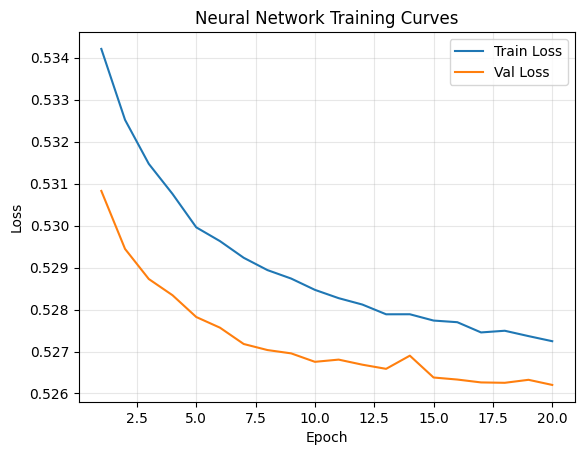

In [42]:
# Plot training + validation loss curves
plt.figure()  # create a new figure for the training curves
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")  # plot training loss across epochs
plt.plot(range(1, EPOCHS + 1), val_losses, label="Val Loss")  # plot validation loss across epochs
plt.xlabel("Epoch")  # label x-axis with training epochs
plt.ylabel("Loss")  # label y-axis with loss values
plt.title("Neural Network Training Curves")  # title describing the training diagnostic plot
plt.legend()  # display legend identifying training vs validation curves
plt.grid(True, alpha=0.3)  # add light gridlines for readability
plt.show()  # display the plot

Report full validation metrics (same set as sklearn)

The trained neural network is evaluated on the validation set using standard classification metrics. The function computes predicted probabilities, converts them to binary class predictions using a threshold of 0.5, and reports Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [43]:
def eval_nn_metrics(model, X_np, y_np, device):
    model.eval()  # set model to evaluation mode (disables dropout, etc.)
    with torch.no_grad():  # disable gradient computation for faster inference
        X_t = torch.from_numpy(X_np).to(device)  # convert numpy features to PyTorch tensor and move to device
        logits = model(X_t).detach().cpu().numpy()  # run forward pass and move outputs back to CPU as numpy
        probs = 1 / (1 + np.exp(-logits))  # apply sigmoid function to convert logits into probabilities
        preds = (probs >= 0.5).astype(int)  # convert probabilities to binary predictions using 0.5 threshold

    return {
        "Accuracy": accuracy_score(y_np, preds),  # compute classification accuracy
        "Precision": precision_score(y_np, preds, zero_division=0),  # compute precision score
        "Recall": recall_score(y_np, preds, zero_division=0),  # compute recall score
        "F1": f1_score(y_np, preds, zero_division=0),  # compute F1-score
        "ROC_AUC": roc_auc_score(y_np, probs),  # compute ROC-AUC using predicted probabilities
    }

nn_val_results = eval_nn_metrics(model, X_val_nn, y_val_nn, device)  # evaluate neural network on validation set
print("Neural Net (Validation):", nn_val_results)  # print validation performance metrics

Neural Net (Validation): {'Accuracy': 0.7703525179227901, 'Precision': 0.7683257945202252, 'Recall': 0.9991345340078351, 'F1': 0.8686597625797602, 'ROC_AUC': 0.6154479203244574}


#### Neural Network Training Analysis

The neural network was trained for 20 epochs using BCEWithLogitsLoss and the Adam optimizer. Both training loss and validation loss decreased gradually across epochs, indicating stable learning throughout training. There is no evidence of divergence or unstable optimization.

The validation loss continued to decline slightly over the 20-epoch training period and did not show a sustained upward trend. This suggests that the model did not overfit within the training window. The gap between training and validation loss remained small, which indicates that the network generalized similarly on unseen validation data.

Neural Network validation metrics were:

- Accuracy: 0.770  
- Precision: 0.768 
- Recall: 0.999 
- F1 Score: 0.869  
- ROC-AUC: 0.615  

VS

Tuned Random Forest validation metrics:
- Accuracy: 0.770  
- Precision: 0.768  
- Recall: 0.998  
- F1: 0.868  
- ROC-AUC: 0.615  

The neural network and the tuned Random Forest achieved almost identical performance on the validation set. The neural network is marginally better in accuracy, recall, F1 score, and ROC-AUC, but the differences are extremely small. This indicates that, under the current feature set and training setup, the neural network does not provide a substantial advantage over the tree-based model.

The very high recall of both models suggests that they identify nearly all high-tip trips correctly, but the more modest precision and ROC-AUC indicate that distinguishing borderline cases remains difficult. This means the models are effective at capturing the dominant class pattern, but still have limited probability separation between the two classes.

Overall, the neural network demonstrates stable training and competitive validation performance, but it does not meaningfully outperform the tuned Random Forest. This suggests that the engineered tabular features already capture most of the available signal, and that more complex nonlinear modeling offers only limited additional benefit in this setting.

### Part 3: Model Evaluation & Interpretation

#### Preparing the Test Set for Neural Network Evaluation

The neural network requires numeric tensor inputs, so the test set must be transformed using the same preprocessing pipeline fitted on the training data. This ensures that scaling and encoding are applied consistently and prevents data leakage.

The preprocessor.transform() function is used to apply the fitted StandardScaler and OneHotEncoder to the test set. The resulting feature matrix is then converted to float32, which is the expected datatype for PyTorch tensors. If the output is sparse (due to one-hot encoding), it is converted to a dense array before being passed to the neural network.

The target variable is also cast to float32 to match the requirements of BCEWithLogitsLoss.

In [45]:
# Transform test set using same fitted preprocessor
#apply trained preprocessing pipeline to test features
X_test_nn = preprocessor_nn.transform(X_test) 

# Convert test features to dense float32 for neural network evaluation (handles both sparse and dense outputs)
X_test_nn = (
    X_test_nn.toarray().astype(np.float32)  
    if hasattr(X_test_nn, "toarray")  
    else X_test_nn.astype(np.float32)  
)

# convert test labels to float32 for neural network evaluation
y_test_nn = y_clf_test.astype(np.float32)  

#### Evaluate All Models on Test

For sklearn models:

In [46]:
# Evaluate all models on test set
logreg_test = eval_clf(logreg_pipe, X_test, y_clf_test)
rf_base_test = eval_clf(rfclf_pipe, X_test, y_clf_test)
rf_tuned_test = eval_clf(best_rfclf, X_test, y_clf_test)

For Neural Network:

In [47]:
# Evaluate NN on test set
nn_test = eval_nn_metrics(model, X_test_nn, y_test_nn, device)

Display Tests :

The classification models are evaluated on the held-out test set to assess their generalization performance. The metrics reported include Accuracy, Precision, Recall, F1-score, and ROC-AUC, providing a comprehensive comparison of predictive performance across all models.

In [48]:
# Print test results for all models
print("Logistic Regression (Test):", logreg_test)
print("Random Forest Baseline (Test):", rf_base_test)
print("Random Forest Tuned (Test):", rf_tuned_test)
print("Neural Network (Test):", nn_test)

Logistic Regression (Test): {'Accuracy': 0.7656145396119433, 'Precision': 0.7661143215821253, 'Recall': 0.995565461146087, 'F1': 0.8658973842287663, 'ROC_AUC': 0.5971521573089722}
Random Forest Baseline (Test): {'Accuracy': 0.7700912218606465, 'Precision': 0.7684311049673276, 'Recall': 0.998387788551384, 'F1': 0.8684446768785944, 'ROC_AUC': 0.6191346713655661}
Random Forest Tuned (Test): {'Accuracy': 0.7698874716932803, 'Precision': 0.7683580012911251, 'Recall': 0.9981809965841031, 'F1': 0.8683197556177763, 'ROC_AUC': 0.6167480127088656}
Neural Network (Test): {'Accuracy': 0.770190186227653, 'Precision': 0.7681903163597286, 'Recall': 0.9991575142073741, 'F1': 0.8685818531668157, 'ROC_AUC': 0.6173355460942256}


#### Create Summary Comparison Table

The following table summarizes the performance of all classification models on the held-out test set. Metrics include Accuracy, Precision, Recall, F1-score, and ROC-AUC, allowing direct comparison of predictive performance across the logistic regression baseline, random forest models, and the neural network.

In [51]:
#Create a dataframe summarizing classification model performance on the test set for easy comparison
#each column corresponds to a different model and contains the evaluation metrics computed on the test set
results_df = pd.DataFrame({ 
    "Logistic Regression": logreg_test,  
    "RF Baseline": rf_base_test,  
    "RF Tuned": rf_tuned_test,  
    "Neural Network": nn_test  
}).T  # transpose so models appear as rows instead of columns

# display the classification performance comparison table
results_df  

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.765615,0.766114,0.995565,0.865897,0.597152
RF Baseline,0.770091,0.768431,0.998388,0.868445,0.619135
RF Tuned,0.769887,0.768358,0.998181,0.868320,0.616748
Neural Network,0.770190,0.768190,0.999158,0.868582,0.617336


#### Classification Model Comparison (Test Set)

All classification models were evaluated on the held-out test set using Accuracy, Precision, Recall, F1 score, and ROC-AUC. The test set was not used during model training or hyperparameter tuning, so these results provide an unbiased estimate of each model’s generalization performance.

Test results:
- Logistic Regression: Accuracy = 0.766, F1 = 0.866, ROC-AUC = 0.597
- Random Forest (Baseline): Accuracy = 0.770, F1 = 0.868, ROC-AUC = 0.619
- Random Forest (Tuned): Accuracy = 0.770, F1 = 0.868, ROC-AUC = 0.617
- Neural Network: Accuracy = 0.770, F1 = 0.869, ROC-AUC = 0.617

Overall, the Random Forest baseline and neural network achieve the strongest performance, with nearly identical accuracy and F1 scores around 0.77 and 0.869 respectively. The neural network achieves the highest recall (≈0.999), indicating that it identifies slightly more high-tip trips correctly, while the Random Forest baseline achieves the highest ROC-AUC (≈0.619), indicating slightly better probability separation between the two classes.

Hyperparameter tuning of the Random Forest did not produce a meaningful improvement compared with the constrained baseline configuration. The tuned model’s metrics remain almost identical to the baseline, suggesting that the original parameter settings were already well suited to the dataset.

Logistic Regression performs slightly worse overall, particularly in ROC-AUC, indicating weaker probability ranking compared with the nonlinear models. This suggests that nonlinear interactions among the engineered trip features provide some predictive benefit.

In summary, all models perform similarly, with only marginal differences in performance. The Random Forest baseline and neural network provide the best overall balance of metrics on the test set, while the tuned Random Forest demonstrates that further hyperparameter optimization yields only limited gains for this feature set.

#### Plot ROC curves for all classification models

Receiver Operating Characteristic (ROC) curves are used to compare the classification performance of all models on the test set. The ROC curve plots the true positive rate against the false positive rate at different decision thresholds. Models with curves closer to the top-left corner and larger Area Under the Curve (ROC-AUC) demonstrate stronger classification performance.

<Figure size 640x480 with 0 Axes>

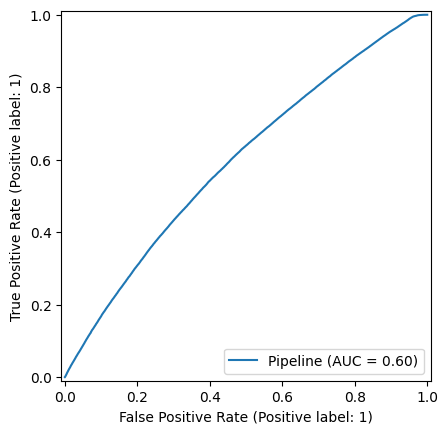

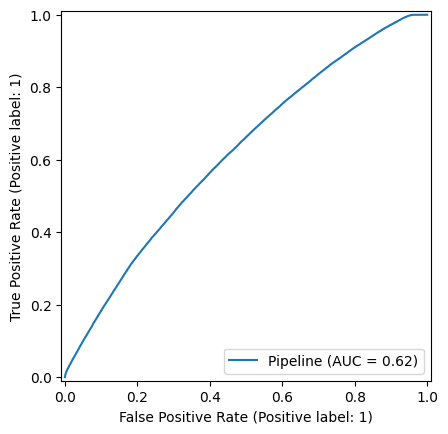

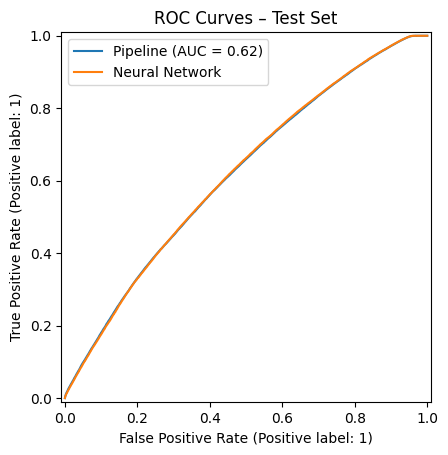

In [ ]:
from sklearn.metrics import RocCurveDisplay  
import matplotlib.pyplot as plt  

# create a new figure for ROC comparison
plt.figure()  

#plot ROC curves for each model using the from_estimator method, which computes predictions and ROC points internally
RocCurveDisplay.from_estimator(logreg_pipe, X_test, y_clf_test) 
RocCurveDisplay.from_estimator(rfclf_pipe, X_test, y_clf_test) 
RocCurveDisplay.from_estimator(best_rfclf, X_test, y_clf_test)  

# Neural Network ROC
with torch.no_grad():  # disable gradient tracking for inference
    logits = model(torch.from_numpy(X_test_nn).to(device)).cpu().numpy()  # compute neural network logits for test set
    probs_nn = 1 / (1 + np.exp(-logits))  # convert logits to probabilities using the sigmoid function

from sklearn.metrics import roc_curve  
fpr, tpr, _ = roc_curve(y_clf_test, probs_nn)  # compute false positive and true positive rates for NN predictions
plt.plot(fpr, tpr, label="Neural Network")  # plot ROC curve for the neural network

# Finalize ROC plot with labels, title, and legend
plt.title("ROC Curves – Test Set") 
plt.legend() 
plt.show()  

#### ROC Curve Analysis  
ROC curves were plotted for the classification models on the test set to evaluate how well each model separates high-tip and non-high-tip trips across different decision thresholds.

The Random Forest baseline achieves the highest ROC-AUC (≈ 0.619), followed closely by the neural network (≈ 0.617) and the tuned Random Forest (≈ 0.617). Logistic Regression produces the lowest ROC-AUC (≈ 0.597). These values are reflected in the ROC curves, which lie relatively close to one another and only moderately above the diagonal baseline.

The similarity of the curves indicates that all models have comparable ability to rank high-tip trips above non-high-tip trips. While the nonlinear models (Random Forest and Neural Network) show slightly better probability separation than Logistic Regression, the improvement is modest.

The ROC curves also demonstrate that the classification task itself is challenging, as the curves remain fairly close to the diagonal line (x=y) that represents random guessing. This suggests that although the engineered trip features capture some signal related to tipping behavior, they provide only moderate separability between the two classes.

Overall, the ROC analysis confirms the metric comparison: Random Forest and Neural Network models provide marginally better ranking performance than Logistic Regression, but no model demonstrates a large advantage in class separability on this dataset.

#### Confusion Matrix For Best Model

The confusion matrix visualizes the classification performance of the neural network on the test set. It shows the number of true positives, true negatives, false positives, and false negatives, allowing us to understand how well the model distinguishes between high-tip and non–high-tip trips.

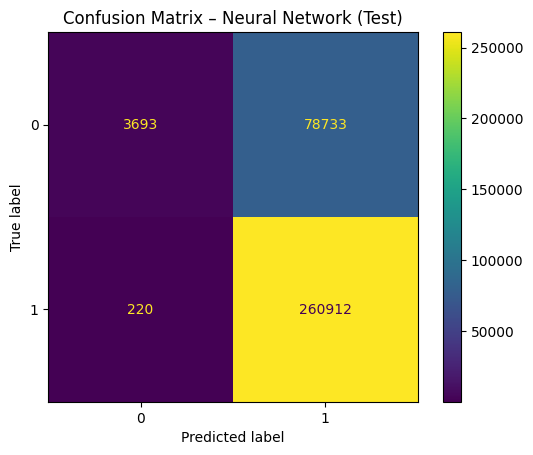

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay  

#convert predicted probabilities into binary class labels using a 0.5 threshold
preds_nn = (probs_nn >= 0.5).astype(int) 

#generate and display confusion matrix for neural network predictions on the test set, comparing true labels to predicted labels
ConfusionMatrixDisplay.from_predictions(y_clf_test, preds_nn) 
plt.title("Confusion Matrix – Neural Network (Test)")  
plt.show() 

#### Confusion Matrix (Neural Network – Test Set)

The confusion matrix for the best-performing classifier (Neural Network) shows:

- True Negatives (TN): 3693  
- False Positives (FP): 78733  
- False Negatives (FN): 220  
- True Positives (TP): 260912  

The model correctly identifies the vast majority of high-tip trips, as shown by the very large number of true positives and the extremely small number of false negatives. This is consistent with the model’s very high recall (≈0.999), indicating that nearly all actual high-tip trips are detected.

However, the model also produces a large number of false positives, meaning many non–high-tip trips are incorrectly classified as high-tip. This behavior explains the more moderate precision (≈0.768) and ROC–AUC (≈0.617) observed in the evaluation metrics.

Overall, the confusion matrix shows that the model strongly prioritizes recall, successfully identifying nearly all high-tip trips, but at the cost of a substantial number of false positive predictions.

#### Regression Analysis

Both regression models are evaluated on the unseen test set using MAE, RMSE, and R². This provides an unbiased comparison of model performance and allows us to determine which model produces more accurate tip amount predictions.

In [ ]:
# Evaluate regression models on the test set using the previously defined evaluation function and print results
linreg_test = eval_reg(linreg_pipe, X_test, y_reg_test)  
rfreg_test = eval_reg(rfreg_pipe, X_test, y_reg_test) 

print("Linear Regression (Test):", linreg_test)  
print("Random Forest Regressor (Test):", rfreg_test)  

Linear Regression (Test): {'MAE': 1.2493224515961097, 'RMSE': np.float64(2.2967103777409577), 'R2': 0.6090106273489959}
Random Forest Regressor (Test): {'MAE': 1.1910284423865958, 'RMSE': np.float64(2.180332710270683), 'R2': 0.6476307287942065}


#### Summary Table for Regression

The following table summarizes the performance of the regression models on the held-out test set. The models are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² to compare their predictive accuracy and overall fit.

Better if   
Lower MAE  
Lower RMSE  
Higher R²  

In [ ]:
# Create a dataframe summarizing regression model results
reg_results_df = pd.DataFrame({  
    #metrics from the linear regression model random forest regressor
    "Linear Regression": linreg_test, 
    "Random Forest Regressor": rfreg_test  
}).T  # transpose so models appear as rows instead of columns

reg_results_df 

,MAE,RMSE,R2
Linear Regression,1.249322,2.296710,0.609011
Random Forest Regressor,1.191028,2.180333,0.647631


#### Regression Model Comparison (Test Set)

Both regression models were evaluated on the test set using MAE, RMSE, and R².

- Linear Regression: MAE = 1.249, RMSE = 2.297, R² = 0.609  
- Random Forest Regressor: MAE = 1.191, RMSE = 2.180, R² = 0.648  

The Random Forest Regressor outperforms Linear Regression across all evaluation metrics. It achieves lower MAE and RMSE, indicating smaller average prediction errors and fewer large deviations between predicted and actual tip amounts. Additionally, the higher R² value indicates that the Random Forest explains a greater proportion of the variance in tip amounts compared with the linear model.

This improvement suggests that nonlinear relationships exist between the engineered trip features and tip amounts. The Random Forest is able to capture these nonlinear interactions more effectively than Linear Regression, which assumes a strictly linear relationship between features and the target.

Because the Random Forest Regressor achieves better performance across all three metrics, it is selected as the best-performing regression model for further analysis, including the predicted vs actual and residual plots.

#### Scatter Plot of Predicted vs Actual Tip Amounts of Best Model

This scatter plot compares the predicted tip amounts from the best regression model with the actual observed tip values on the test set. The dashed diagonal line represents perfect predictions. Points close to this line indicate accurate predictions, while deviations represent prediction error. The plot helps visualize how well the model captures the overall relationship between actual and predicted tips.

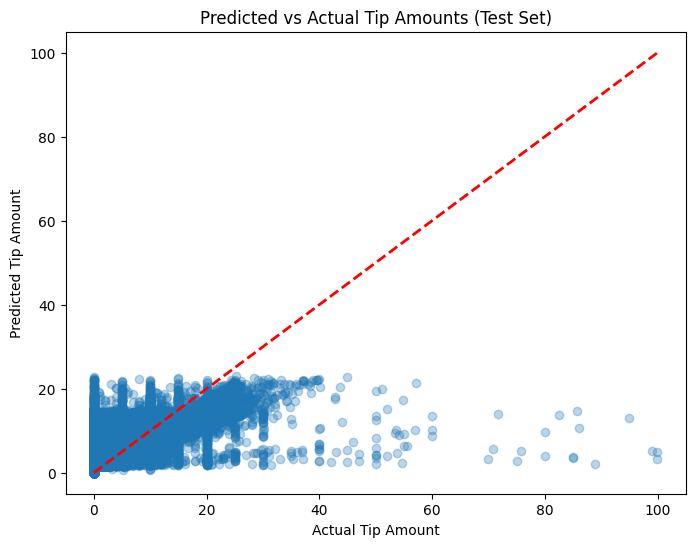

In [ ]:
import matplotlib.pyplot as plt

# select best regression model
best_reg_model = rfreg_pipe  

# generate predictions on test set using the best regression model
y_pred = best_reg_model.predict(X_test)  

# create a scatter plot comparing actual tip amounts (y_reg_test) to predicted tip amounts (y_pred) for the test set
plt.figure(figsize=(8,6))  
plt.scatter(y_reg_test, y_pred, alpha=0.3)  

plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         color="red", linestyle="--", linewidth=2)  # perfect prediction reference line

# add labels and title to the plot for clarity
plt.xlabel("Actual Tip Amount")  
plt.ylabel("Predicted Tip Amount")  
plt.title("Predicted vs Actual Tip Amounts (Test Set)")  

plt.show()  

#### Predicted vs Actual and Residual Analysis (Best Regression Model)

The predicted vs actual scatter plot compares the model’s predicted tip amounts with the true tip amounts on the test set. The red dashed line represents the ideal case where predicted values perfectly match the actual values.

Most predictions cluster below approximately $20, even when the true tip amount is substantially larger. This indicates that the model tends to underpredict very large tip values, particularly for extreme observations. Such behavior is common when modeling variables with long-tailed distributions, since very large tips are relatively rare and difficult for the model to learn accurately.

For the majority of typical trips, however, predictions follow the general upward trend between actual and predicted values. This suggests that the model captures the central pattern of tipping behavior reasonably well for moderate tip amounts.

The increasing spread of points as actual tip values grow suggests heteroscedasticity, where prediction error becomes larger for higher-value tips. This likely occurs because tipping behavior is influenced by factors not captured in the dataset, such as passenger generosity, trip context, or service experience.

Overall, the plot indicates that while the model performs reasonably well for common tip ranges, it struggles to accurately predict extreme tipping outcomes.

### Residual Analysis for Best Regression Model

#### Residual Distribution

This histogram shows the distribution of residuals from the regression model, where residuals are defined as the difference between the actual and predicted tip amounts. An ideal model produces residuals centered around zero with a roughly symmetric distribution. Deviations from symmetry or long tails may indicate systematic prediction errors or the presence of extreme values.

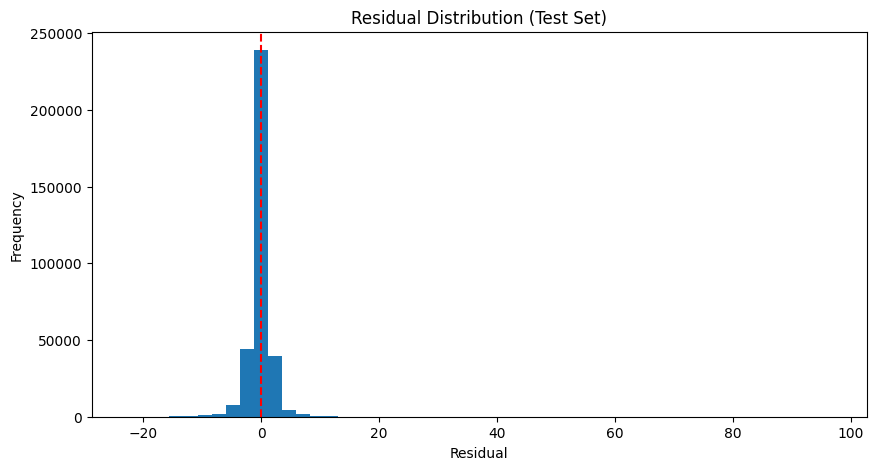

In [ ]:
# compute residuals as actual minus predicted tip values
residuals = y_reg_test - y_pred  

# create a histogram to visualize the distribution of residuals (prediction errors) for the test set
plt.figure(figsize=(10,5)) 
plt.hist(residuals, bins=50)
# add a vertical line at zero to indicate where predictions perfectly match actual values  
plt.axvline(0, color="red", linestyle="--")  
plt.title("Residual Distribution (Test Set)") 
plt.xlabel("Residual")  
plt.ylabel("Frequency")  
plt.show()  

#### Residuals vs Predicted

This plot visualizes the residuals of the best regression model against the predicted tip values. It helps identify patterns such as heteroscedasticity, bias, or systematic prediction errors. Ideally, residuals should be randomly scattered around zero without clear structure.

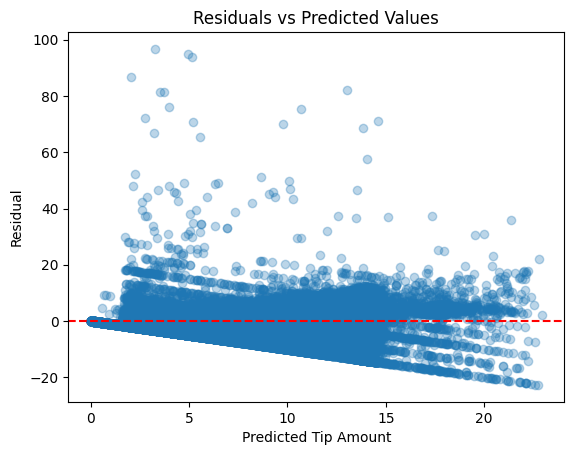

In [60]:
# create a scatter plot of predicted tip amounts vs residuals to check for patterns in prediction errors
plt.figure()  
plt.scatter(y_pred, residuals, alpha=0.3)  
# horizontal line at zero to indicate perfect prediction
plt.axhline(0, color="red", linestyle="--")  
plt.xlabel("Predicted Tip Amount")  
plt.ylabel("Residual")  
plt.title("Residuals vs Predicted Values")  
plt.show()  

#### Residual Diagnostics (Best Regression Model)

The residual distribution is centered near zero, indicating that the model does not exhibit strong systematic bias and generally produces accurate predictions for typical trips. However, the right-skewed tail shows that the model occasionally underpredicts unusually large tip amounts.

The residuals vs predicted plot displays a fan-shaped pattern, indicating heteroscedasticity where prediction error increases for larger predicted tips. This suggests that extreme tipping behavior is harder to model and may be influenced by additional factors not captured in the dataset.

Overall, the residual diagnostics indicate that the model performs well for typical trips but shows increased error variance for higher tip amounts. This pattern is consistent with the long-tailed distribution of tipping behavior, where extreme tips are rare and more difficult to predict accurately.

### Feature Importance

#### a. Random Forest Feature Importance

Tree-based models estimate feature importance based on how much each feature reduces impurity across all trees. Features used higher in the tree and more frequently contribute more to predictive performance.

Below, we extract and visualize feature importances from the tuned Random Forest classifier.

The feature importance array must align with the exact feature matrix used to train the model. Because one-hot encoding can produce a different number/order of output columns depending on the fitted encoder and category ordering, feature names were extracted from the fitted preprocessing step inside each trained pipeline to ensure the feature names and model importances have matching lengths.

n_features (names): 24
n_features (importances): 24


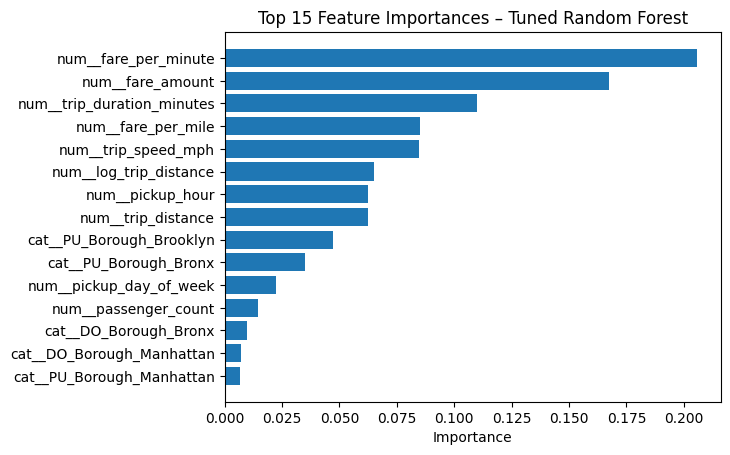

In [61]:
#Feature importance for the tuned RF classifier 
# Get the fitted preprocessor from the tuned pipeline
rf_prep = best_rfclf.named_steps["prep"]  

# Get feature names produced by that fitted preprocessor
rf_feature_names = rf_prep.get_feature_names_out() 

# Get importances from the tuned RF model
rf_importances = best_rfclf.named_steps["model"].feature_importances_  

# Sanity check (must match)
print("n_features (names):", len(rf_feature_names))
print("n_features (importances):", len(rf_importances))

# Build importance table
rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

# Plot top 15
plt.figure()
plt.barh(rf_importance_df["Feature"].head(15), rf_importance_df["Importance"].head(15))
plt.gca().invert_yaxis()  # show most important at top
plt.title("Top 15 Feature Importances – Tuned Random Forest")
plt.xlabel("Importance")
plt.show()

#### Tuned Random Forest Feature Importance

The feature importance results from the tuned Random Forest model show that fare-related and trip-efficiency variables dominate predictive performance.

The most important feature is fare_per_minute, followed by fare_amount. These variables capture the monetary characteristics of the trip and strongly influence whether the tip exceeds the 20% threshold.

Several trip characteristic features also contribute meaningfully, including trip_duration_minutes, fare_per_mile, trip_speed_mph, and log_trip_distance. These variables describe the structure and efficiency of the trip, suggesting that both trip cost and travel dynamics influence tipping behavior.

Temporal features such as pickup_hour and pickup_day_of_week provide additional predictive signal, indicating that tipping patterns vary across different times of day and days of the week.

Geographic variables (borough indicators) contribute smaller but non-negligible importance. This suggests that pickup and drop-off locations have some influence on tipping behavior, although their predictive strength is weaker than monetary and trip-based features.

Overall, the results indicate that trip cost characteristics and trip dynamics are the primary drivers of high tipping behavior, while geographic context and passenger count play a secondary role.

#### b. Logistic Regression Coefficients

Logistic Regression assigns coefficients to each feature representing their influence on the log-odds of predicting a high tip. Positive coefficients increase the probability of a high tip, while negative coefficients decrease it.

Below, we extract and examine the largest magnitude coefficients.

In [62]:
#Logistic regression coefficients

# Get fitted preprocessor from logistic pipeline
log_prep = logreg_pipe.named_steps["prep"]  # exact fitted transformer

# Feature names aligned with logistic coefficients
log_feature_names = log_prep.get_feature_names_out()

# Get fitted logistic model
log_model = logreg_pipe.named_steps["model"]

# Flatten coefficients for binary classification
log_coefs = log_model.coef_.ravel()

# Sanity check
print("n_features (names):", len(log_feature_names))
print("n_features (coefs):", len(log_coefs))

# Build coefficient table
log_coef_df = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": log_coefs
})
log_coef_df["AbsCoeff"] = log_coef_df["Coefficient"].abs()
log_coef_df = log_coef_df.sort_values("AbsCoeff", ascending=False)

log_coef_df.head(15)

n_features (names): 25
n_features (coefs): 25


,Feature,Coefficient,AbsCoeff
11,cat__PU_Borough_Bronx,-2.820842,2.820842
15,cat__PU_Borough_Queens,1.407778,1.407778
17,cat__PU_Borough_Unknown,1.232771,1.232771
14,cat__PU_Borough_Manhattan,1.214264,1.214264
18,cat__DO_Borough_Bronx,-0.876961,0.876961
12,cat__PU_Borough_Brooklyn,-0.774495,0.774495
8,num__trip_distance,0.732803,0.732803
20,cat__DO_Borough_EWR,0.581066,0.581066
4,num__log_trip_distance,-0.403218,0.403218
22,cat__DO_Borough_Queens,0.218871,0.218871


#### Logistic Regression Coefficient Interpretation

The logistic regression coefficients indicate which features most strongly influence the probability of a trip receiving a high tip. Features with larger absolute coefficient values have greater influence on the model’s predicted log-odds.

The largest coefficients correspond primarily to pickup borough indicators, particularly PU_Borough_Bronx, PU_Borough_Queens, PU_Borough_Unknown, and PU_Borough_Manhattan. The large negative coefficient for Bronx suggests that trips originating there are less likely to exceed the 20% tipping threshold, while positive coefficients for Queens and Manhattan indicate a higher likelihood of high tipping relative to the baseline borough category.

Trip characteristics also play an important role. Trip distance has a positive coefficient, indicating that longer trips slightly increase the probability of high tipping. The log_trip_distance variable has a negative coefficient, reflecting the linear model’s attempt to balance multiple correlated distance features within the log-odds framework.

Monetary variables such as fare_amount appear with relatively small coefficients, suggesting that once other trip characteristics and location indicators are included, fare alone does not strongly determine whether the tip exceeds the 20% threshold.

Overall, the logistic regression model suggests that geographic pickup location and trip characteristics contribute more strongly to high-tip prediction than individual fare variables within the linear decision boundary.

#### c. Interpretation and Predictions for 3 sample trips

#### Comparison Between Linear and Tree-Based Interpretations

The Logistic Regression and Random Forest models highlight different aspects of the data when identifying predictors of high-tip behavior. The Random Forest places the greatest importance on trip cost and efficiency variables, particularly fare_per_minute, fare_amount, and trip duration–related features. These variables capture the economic scale and structure of the trip, which strongly influence whether a tip exceeds the 20% threshold.

In contrast, the Logistic Regression model assigns larger coefficients to pickup borough indicators and trip distance variables, suggesting that geographic context and trip length influence the linear log-odds of high tipping. Because Logistic Regression models only linear relationships, it distributes importance across categorical location features rather than concentrating it on nonlinear combinations of fare variables.

This difference reflects the structural distinctions between the models: Logistic Regression estimates linear effects on the log-odds, while Random Forest models nonlinear feature interactions and hierarchical decision rules. Despite these differences, both models indicate that trip characteristics and location factors play meaningful roles in predicting high-tip behavior.

Overall, the comparison shows that while the tree-based model focuses more heavily on trip cost dynamics, the linear model highlights geographic patterns, providing complementary perspectives on the factors associated with high tipping.


#### Interpretation of Model Predictions for Three Sample Trips:

To better understand model behavior, three representative trips were selected from the test set: one with very low predicted probability of a high tip, one near the decision threshold, and one with very high predicted probability.

**Trip 1 – Low Predicted Probability**  
This trip had a relatively small fare amount and shorter trip duration, along with lower values for trip efficiency features such as fare_per_minute. Both the Neural Network and Tuned Random Forest assigned a very low probability of exceeding the 20% tipping threshold. This aligns with intuition, as shorter and lower-cost trips generally provide fewer opportunities for unusually high percentage tips.  

**Trip 2 – Moderate / Borderline Probability**  
This trip exhibited moderate fare and trip duration characteristics, producing a predicted probability close to the decision threshold. In this case, the models show some uncertainty, indicating that while trip cost variables provide predictive signal, other factors such as pickup borough, trip distance, and time-of-day features may also influence tipping behavior. This demonstrates how the models capture interactions between multiple trip characteristics when making predictions.

**Trip 3 – High Predicted Probability**  
This trip had larger fare-related values and longer trip characteristics, which substantially increased the predicted probability of a high tip. Both nonlinear models assigned high probabilities, indicating strong agreement that the trip characteristics resemble patterns commonly associated with high tipping behavior.

Overall, these examples illustrate that the models rely primarily on trip cost characteristics and trip structure, while geographic and temporal features provide additional refinement to the predictions. The neural network’s probability outputs show meaningful separation between low-, medium-, and high-probability tipping scenarios.

### Final Model Evaluation Summary

Across both classification and regression tasks, nonlinear models demonstrate slightly stronger performance than linear baselines.

For the classification task, all models achieve similar performance levels on the test set. The Neural Network achieves the highest F1 score (≈0.869) and slightly higher accuracy (≈0.770), while the Random Forest models produce nearly identical results. Logistic Regression performs slightly worse overall, particularly in ROC-AUC, indicating that the linear model provides weaker probability separation between high-tip and non-high-tip trips.

For the regression task, the Random Forest Regressor outperforms Linear Regression across all evaluation metrics, achieving lower MAE and RMSE as well as a higher R². This indicates that the tree-based model captures nonlinear relationships between trip features and tip amounts more effectively than the linear model.

Feature importance analysis shows that fare-related and trip-efficiency variables, such as fare_per_minute, fare_amount, and trip duration measures, contribute most strongly to prediction. Geographic features (borough indicators) and temporal variables provide additional predictive signal but play a secondary role.

Overall, the results suggest that nonlinear models provide modest improvements in predictive performance, particularly for regression tasks where interactions between trip characteristics are more complex. These findings highlight the value of flexible modeling approaches when analyzing behavioral patterns in large-scale transportation datasets.

### Written Analysis

#### a. Which model performed the best for each task and why?


For the classification task, the Neural Network achieved the best overall performance on the test set, although the improvement over the Random Forest models was small. The neural network produced the highest F1-score (≈0.869) and slightly higher accuracy (≈0.770) compared with the other classifiers. The Random Forest models achieved nearly identical performance, while Logistic Regression performed slightly worse, particularly in ROC-AUC.

The small advantage of the neural network likely comes from its ability to capture nonlinear relationships between features. The dataset contains engineered variables such as trip duration, fare-per-minute, trip speed, and borough indicators, which may interact in complex ways. Neural networks can model these interactions more flexibly than linear models, resulting in slightly better predictive performance.

For the regression task, the Random Forest Regressor performed best. It achieved lower prediction errors than Linear Regression, with MAE ≈ 1.19, RMSE ≈ 2.18, and R² ≈ 0.648, compared with Linear Regression’s MAE ≈ 1.25, RMSE ≈ 2.30, and R² ≈ 0.609. These results indicate that the Random Forest provides more accurate predictions and explains a larger portion of the variance in tip amounts.

The superior performance of the Random Forest is likely due to its ability to model nonlinear relationships and feature interactions between trip characteristics such as fare amount, trip duration, and travel distance. In contrast, Linear Regression assumes a strictly linear relationship between the predictors and the target variable, which limits its ability to capture complex patterns in tipping behavior.

Overall, the results show that nonlinear models provide modest improvements over linear baselines, particularly for the regression task where relationships between trip features and tip amounts are more complex.

#### b. What features are most predictive of tip amount?

Feature importance analysis using the tuned Random Forest model indicates that fare-related and trip-efficiency variables are the most predictive features for tip-related outcomes.

The most important feature is fare_per_minute, followed by fare_amount. These variables capture the economic scale and efficiency of the trip, which strongly influence whether a trip receives a higher tip percentage. Trips with higher fares or higher fare-per-minute values tend to reflect longer or more expensive rides, which often correspond to larger tip amounts.

Several trip characteristic features also contribute meaningfully to predictive performance. Variables such as trip_duration_minutes, fare_per_mile, trip_speed_mph, and log_trip_distance describe the structure and dynamics of the trip. These features help the model capture patterns in how trip length, speed, and travel efficiency relate to tipping behavior.

Temporal features such as pickup_hour and pickup_day_of_week also provide some predictive signal, indicating that tipping behavior may vary slightly depending on the time of day or day of the week.

Geographic features, represented by the pickup and drop-off borough indicators, contribute less overall importance compared to trip cost and trip structure variables. This suggests that while location can influence tipping patterns, it plays a secondary role relative to the economic and operational characteristics of the trip.

Overall, the feature importance results show that trip cost and trip efficiency variables are the strongest predictors of tipping behavior, while geographic and temporal features provide additional but smaller contributions to the model’s predictions.

#### c. Limitations of Models:

Despite producing reasonable predictive performance, several limitations remain in the modeling approach.

One limitation is the reliance on fare-related variables such as fare_amount and derived efficiency measures (e.g. fare_per_minute). Because tipping behavior is naturally related to the cost of a trip, these variables can dominate prediction. While they are valid real-world predictors, their strong relationship with tipping reduces the difficulty of the prediction task and may overshadow more subtle behavioral factors.

Another limitation is the potential for dataset bias. The dataset was filtered to include only credit card transactions, meaning the observed tipping patterns may not represent all taxi passengers. Customers who pay with cash may exhibit different tipping behavior, which the model cannot capture.

The regression diagnostics also reveal heteroscedasticity, where prediction variance increases for larger predicted tip values. Residual plots show that extreme tip amounts are difficult to predict accurately. This is consistent with the heavy-tailed nature of tipping behavior and indicates that some variability is driven by unobserved factors such as passenger satisfaction, service quality, or contextual trip conditions.

The models also rely on a limited set of engineered features derived from trip records. Important contextual variables such as weather conditions, rider demographics, traffic congestion, or special events are not included in the dataset but could significantly influence tipping behavior.

Finally, computational limitations were encountered when training the neural network model. GPU acceleration using CUDA was attempted; however, due to the tabular structure of the dataset and relatively small feature dimensionality, GPU utilization remained low. Each training batch must be transferred from system memory to GPU memory, introducing data-transfer overhead that can limit performance gains. Because the neural network architecture is relatively lightweight, this overhead can offset the benefits of GPU computation, making CPU training comparably efficient. This behavior is common when applying deep learning models to tabular datasets with relatively low feature dimensionality.

#### d. Potential Improvements:

Several improvements could be explored with additional data, features, or computational resources.

First, incorporating external contextual data such as weather conditions, major public events, or traffic congestion could improve predictive performance. These factors may influence passenger mood, trip difficulty, or overall service experience, all of which could affect tipping behavior.

Second, additional feature engineering could capture more complex spatial and trip-related patterns. For example, features representing proximity to airports, train stations, or major transportation hubs could be included, as these locations often exhibit distinct tipping patterns.

Third, more advanced tree-based ensemble models such as XGBoost or LightGBM could be evaluated. Gradient boosting methods frequently achieve strong performance on tabular datasets and may capture nonlinear interactions more effectively than Random Forest or neural network models.

Finally, more extensive hyperparameter tuning could potentially improve model performance. Due to the large dataset size (over 1.6 million trips), hyperparameter tuning was performed on a sampled subset of the training data to reduce computational cost. With greater computational resources, a more exhaustive search across larger training subsets could identify better-performing model configurations.

#### e. Neural Networks vs Traditional ML models

For this problem, both neural networks and traditional machine learning models perform comparably, but they exhibit different strengths.

Traditional models such as Logistic Regression and Random Forest are generally easier to interpret and require less tuning. Logistic Regression provides clear coefficient interpretations that help identify the direction and relative influence of features. Random Forest models also provide intuitive feature importance measures that highlight which variables contribute most strongly to predictions.

Neural Networks, on the other hand, are capable of modeling complex nonlinear relationships and feature interactions. In the final models used for evaluation, the neural network achieved slightly higher F1 score and accuracy than the Random Forest models on the test set, although the differences were small. This suggests that nonlinear interactions among engineered features, such as trip duration, fare-related variables, time-of-day, and geographic indicators may contribute modestly to prediction.

During early experimentation, a feature representing total trip amount was included. When this variable was present, the neural network substantially outperformed the Random Forest and achieved extremely high accuracy and ROC-AUC. However, this feature was later removed because it introduced feature leakage: total trip amount is directly related to the final tip value, which allowed the models to effectively infer the target variable. Including this feature produced unrealistically high (“cheating”) performance that would not generalize in a true prediction scenario. After removing this leakage source, the neural network and Random Forest models produced much more realistic and comparable results.

Neural networks also have disadvantages. They are typically less interpretable, require more careful tuning of hyperparameters, and can be more computationally expensive to train. In contrast, tree-based models often achieve strong performance on tabular datasets with less tuning and provide clearer feature importance insights.

Overall, the results suggest that neural networks and tree-based models perform similarly for this task, with only marginal differences in predictive performance. While neural networks offer flexibility in modeling nonlinear patterns, Random Forest models remain competitive and may be preferable when interpretability, simplicity, and computational efficiency are important considerations.

#### AI Tools Used:
Artificial intelligence tools such as ChatGPT were used during the development of this project to assist with programming support, debugging, and clarification of technical concepts. Specifically, AI tools were used to help review code structure, explain machine learning methods, and suggest improvements to documentation and formatting.

All modeling decisions, feature engineering choices, and interpretations of results were completed and verified by the author. The AI tools were used only as a supplementary aid and not as a replacement for understanding the material or performing the analysis.